In [6]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

In [ ]:
#Dataset
torch.random.manual_seed(42)
unlabeled = 20
num_classes = 2
label_budget = 4
data = torch.empty(unlabeled, num_classes).uniform_(-1, 1)
labels = (data[:, 1] >= data[:, 0]).float().unsqueeze(1)
from itertools import combinations
all_subsets = list(combinations(range(unlabeled), label_budget))
x_all = torch.stack([data[list(subset)] for subset in all_subsets])
y_all = torch.stack([labels[list(subset)] for subset in all_subsets])
print(x_all.shape)
print(y_all.shape)

torch.Size([4845, 4, 2])
torch.Size([4845, 4, 1])


In [11]:
# x @ W.T + b
N = len(all_subsets) #number of subsets of size 4 from 30 samples = C(30, 4) = 27405
W = torch.randn(N, 1, 2, requires_grad=True)
b = torch.randn(N, 1, requires_grad=True) 
#criterion = nn.BCEWithLogitsLoss()

criterion = nn.BCEWithLogitsLoss() # test Training loop
optimizer = torch.optim.SGD([W, b], lr=0.1)

In [12]:
# Training Loop
losses = []
for epoch in range(100):
    optimizer.zero_grad()
    logits = x_all @ W.transpose(-1, -2) + b.unsqueeze(1)
    loss = criterion(logits, y_all)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
print(f'Final Loss: {loss.item():.4f}')

Final Loss: 0.8700


In [5]:
# Test Training loop
'''losses_all = []  # 改成記錄所有 NN 的 loss
for epoch in range(100):
    optimizer.zero_grad()
    logits = x_all @ W.transpose(-1, -2) + b.unsqueeze(1)
     # 不取平均，對每個 NN 單獨算 loss，再加總
    loss_per_nn = criterion(logits, y_all)
    loss = loss_per_nn.mean(dim=[1, 2]).sum()  # 先對 batch 平均，再對 N 加總
    loss.backward()
    optimizer.step()
    losses_all.append(loss_per_nn.detach().cpu())  # 記錄每個 NN 的 loss'''
 

'losses_all = []  # 改成記錄所有 NN 的 loss\nfor epoch in range(100):\n    optimizer.zero_grad()\n    logits = x_all @ W.transpose(-1, -2) + b.unsqueeze(1)\n     # 不取平均，對每個 NN 單獨算 loss，再加總\n    loss_per_nn = criterion(logits, y_all)\n    loss = loss_per_nn.mean(dim=[1, 2]).sum()  # 先對 batch 平均，再對 N 加總\n    loss.backward()\n    optimizer.step()\n    losses_all.append(loss_per_nn.detach().cpu())  # 記錄每個 NN 的 loss'

In [6]:
'''i = 0  # 第一個 subset
plt.figure(figsize=(8, 5))
plt.plot(losses_all[:, i].numpy())
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title(f'Subset {all_subsets[i]} - Loss Curve')
plt.savefig(f'Training_Loss_Curve {i}.png')'''

"i = 0  # 第一個 subset\nplt.figure(figsize=(8, 5))\nplt.plot(losses_all[:, i].numpy())\nplt.xlabel('Epoch')\nplt.ylabel('Loss')\nplt.title(f'Subset {all_subsets[i]} - Loss Curve')\nplt.savefig(f'Training_Loss_Curve {i}.png')"

In [7]:
# Test Training loop
losses_history = []  # 用來記錄所有 NN 在每一輪的平均 loss

for epoch in range(100):
    optimizer.zero_grad()
    logits = x_all @ W.transpose(-1, -2) + b.unsqueeze(1) # [N, 4, 1]
    
    # 計算每個點的原始 loss: [N, 4, 1]
    loss_per_point = criterion(logits, y_all)
    
    # 對每個 NN 的 4 個點取平均，得到每個 NN 的單一 loss 值: [N]
    loss_per_nn = loss_per_point.mean(dim=[1, 2])
    
    # 為了 backward，對所有 NN 取平均 (這比 sum() 更穩定)
    total_loss = loss_per_nn.mean()
    
    total_loss.backward()
    optimizer.step()
    
    # 記錄這一輪中，所有 27405 個 NN 各自的 loss
    # 存入列表前先轉成 cpu 並 detach
    losses_history.append(loss_per_nn.detach().cpu())

# --- 關鍵修正：將列表轉換為二維 Tensor ---
# 轉換後形狀為 [Epochs, N] -> [100, 27405]
losses_tensor = torch.stack(losses_history)

# Visualization 
i = 4  # 想要觀察的子集索引
plt.figure(figsize=(8, 5))

# 現在你可以安全地使用切片了：[所有輪次, 第 i 個模型]
plt.plot(losses_tensor[:, i].numpy()) 

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title(f'Subset {all_subsets[i]} - Loss Curve')
plt.savefig(f'Training_Loss_Curve_{i}.png')
print(f"模型 {i} 的最終 Loss: {losses_tensor[-1, i]:.4f}")

模型 4 的最終 Loss: 0.3798


In [13]:
#test dataset
test_data = torch.cartesian_prod(torch.linspace(-1, 1, 20), torch.linspace(-1, 1, 20))
test_labels = (test_data[:, 1] >= test_data[:, 0]).float().unsqueeze(1)
test_dataset = TensorDataset(test_data, test_labels)
test_loader = DataLoader(test_dataset, batch_size=400, shuffle=False)

In [14]:
# Evaluate test dataset
with torch.no_grad():
    for x, y in test_loader:
        logits = x.unsqueeze(0) @ W.transpose(-1, -2) + b.unsqueeze(1)
        preds = (logits >= 0).float()
        accuracies = (preds == y.unsqueeze(0)).float().mean(dim=[1, 2])
print(accuracies)
print(accuracies.shape)
print("The maximum accuracy is:", torch.max(accuracies))
print("The maximum accuracy is:", torch.max(accuracies, dim=0))
val = accuracies[len(all_subsets) - 1]
print(val)


tensor([0.5150, 0.6100, 0.2150,  ..., 0.4600, 0.6275, 0.5250])
torch.Size([4845])
The maximum accuracy is: tensor(0.9925)
The maximum accuracy is: torch.return_types.max(
values=tensor(0.9925),
indices=tensor(2857))
tensor(0.5250)


In [10]:
# Visualization

nn_index = 2
print(f"Accuracy for NN index {nn_index}: {accuracies[nn_index].item():.4f}")
preds_first = preds[nn_index].squeeze()
correct = (preds_first == y.squeeze()).numpy()
x_np = x.numpy()

fig, (ax_loss, ax_scatter) = plt.subplots(1, 2, figsize=(12, 5))

ax_loss.plot(losses)
ax_loss.set_xlabel('Epoch')
ax_loss.set_ylabel('Loss')
ax_loss.set_title('Training Losses')

ax_scatter.scatter(x_np[correct, 0], x_np[correct, 1], c='green', marker='o', label='Correct')
ax_scatter.scatter(x_np[~correct, 0], x_np[~correct, 1], c='red', marker='x', label='Incorrect')
ax_scatter.plot([-1, 1], [-1, 1], color='gray', linestyle='--', label='Decision Boundary (x0=x1)')
ax_scatter.set_xlabel('x0')
ax_scatter.set_ylabel('x1')
ax_scatter.set_title('testset classification results')
ax_scatter.legend()

plt.tight_layout()
plt.savefig('NN_result.png')
print('NN_result.png saved')

Accuracy for NN index 2: 0.4150


NameError: name 'losses' is not defined

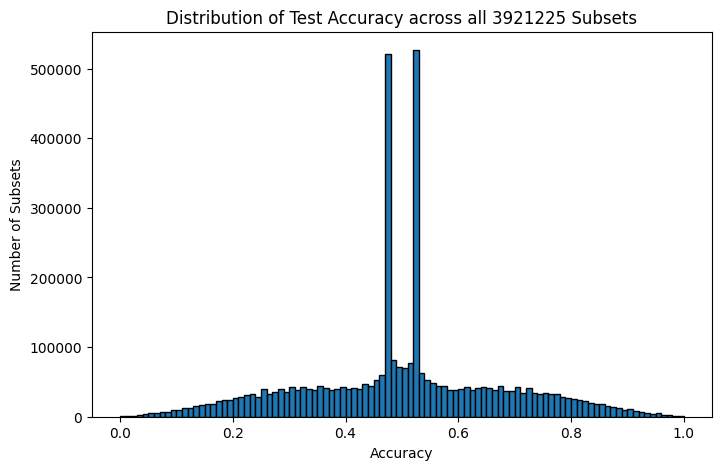

In [ ]:
# Visualization
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(accuracies.numpy(), bins=100, edgecolor='black')
plt.xlabel('Accuracy')
plt.ylabel('Number of Subsets')
plt.title(f'Distribution of Test Accuracy across all {len(all_subsets)} Subsets')
plt.savefig('Distribution')

In [ ]:
# Visualization
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8)) # 稍微加寬圖片，方便容納標籤

# 1. 獲取 hist 的傳回值：n (各柱子的數量), bins (邊界), patches (柱子物件)
n, bins, patches = plt.hist(accuracies.numpy(), bins=100, edgecolor='black')

# 2. 遍歷每一根柱子，並在上方標註數量
for i in range(len(patches)):
    count = n[i]
    if count > 0: # 只標註有數量的柱子，避免 0 填滿畫面
        # 取得柱子的中心位置
        x = patches[i].get_x() + patches[i].get_width() / 2
        y = patches[i].get_height()
        
        # 標註文字
        plt.text(x, y + (max(n)*0.01), str(int(count)), 
                 ha='center', va='bottom', fontsize=8, rotation=90)

plt.xlabel('Accuracy')
plt.ylabel('Number of Subsets')
plt.title(f'Distribution of Test Accuracy across all {len(all_subsets)} (n={unlabeled}, k={label_budget}) Subsets with Counts')
plt.savefig(f'Distribution {len(all_subsets)}, n={unlabeled}, k={label_budget} with Counts.png')

In [ ]:
# visualization of a single subset's distribution
subset_indices = all_subsets[3160]
subset_points = data[list(subset_indices)].numpy()
subset_labels = labels[list(subset_indices)].flatten().numpy()

plt.figure(figsize=(6, 6))
plt.plot([-1, 1], [-1, 1], color='gray', linestyle='--', label='Ideal Boundary ($x_1=x_0$)')

# draw 4 points
for i in range(4):
    color = 'green' if subset_labels[i] == 1 else 'red'
    marker = 'o' if subset_labels[i] == 1 else 'x'
    plt.scatter(subset_points[i, 0], subset_points[i, 1], c=color, marker=marker, s=100)

plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.xlabel('$x_0$')
plt.ylabel('$x_1$')
plt.title(f'Training Points in Subset 3160 (Label Distribution)')
plt.grid(True, alpha=0.3)
plt.legend()

plt.savefig('subset_3160_analysis.png')
print("subset distribution analysis saved.")

In [ ]:
# visualization of unlabeled points' distribution 
data_np = data.numpy()
labels_np = labels.flatten().numpy()

plt.figure(figsize=(7, 7))

class_1 = (labels_np == 1)
class_0 = (labels_np == 0)

plt.scatter(data_np[class_1, 0], data_np[class_1, 1], 
            c='green', marker='o', edgecolors='k', label=r'Class 1 ($x_1 \geq x_0$)')
plt.scatter(data_np[class_0, 0], data_np[class_0, 1], 
            c='red', marker='D', label=r'Class 0 ($x_1 < x_0$)')
plt.plot([-1, 1], [-1, 1], color='gray', linestyle='--', linewidth=1, label='Ideal Boundary')

# 5. 設定座標細節
plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.xlabel('$x_0$')
plt.ylabel('$x_1$')
plt.title(f'Distribution of all {len(data_np)} Unlabeled Points (Pool Set)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.2)

# 6. 儲存圖片
plt.savefig('all_pool_points.png')
print(f"all_pool_points.png，total {len(data_np)} points。")

In [ ]:
# 1. 設定目標範圍
target_acc = 0.30
tolerance = 0.01

# 2. 找出符合條件的索引
indices_near_030 = torch.where((accuracies >= target_acc - tolerance) & 
                               (accuracies <= target_acc + tolerance))[0]

print(f"找到 {len(indices_near_030)} 個 Accuracy 接近 0.30 的子集")

# 3. 隨機抽出 100 個 (如果不足 100 個就全取)
num_samples = min(100, len(indices_near_030))
selected_indices = indices_near_030[torch.randperm(len(indices_near_030))[:num_samples]]

# 取得原始 20 個點的資料
data_np = data.cpu().numpy()
labels_np = labels.flatten().cpu().numpy()

# 統計這 100 個子集中，每個原始點被選中的次數
point_counts30 = np.zeros(len(data))
for idx in selected_indices:
    subset = all_subsets[idx]
    for p_idx in subset:
        point_counts30[p_idx] += 1

# 開始繪圖
plt.figure(figsize=(8, 8))

# 畫出理想邊界
plt.plot([-1, 1], [-1, 1], color='gray', linestyle='--', alpha=0.5, label='Ideal Boundary')

# 畫出所有 20 個點，大小根據被「平庸子集」選中的頻率決定
# 如果一個點被選中很多次，代表它可能是造成 0.30 準確率的「元兇」
for i in range(len(data)):
    color = 'green' if labels_np[i] == 1 else 'red'
    marker = 'o' if labels_np[i] == 1 else 'x'
    # 點的大小 s 與出現次數成正比
    size = 20 + (point_counts30[i] * 20) 
    plt.scatter(data_np[i, 0], data_np[i, 1], c=color, marker=marker, s=size, edgecolors='k', alpha=0.6)

plt.title(f'Point Distribution of {num_samples} Subsets (Acc ≈ 0.30)\nLarger points appear more frequently in these subsets')
plt.xlabel('x0')
plt.ylabel('x1')
plt.grid(True, alpha=0.2)
plt.savefig('Analysis_030_Points.png')

In [ ]:
# 假設你已經跑完了訓練並得到了 accuracies 張量 (形狀為 [4845])
# 1. 設定目標範圍
target_acc = 0.47
tolerance = 0.01

# 2. 找出符合條件的索引
indices_near_047 = torch.where((accuracies >= target_acc - tolerance) & 
                               (accuracies <= target_acc + tolerance))[0]

print(f"找到 {len(indices_near_047)} 個 Accuracy 接近 0.47 的子集")

# 3. 隨機抽出 100 個 (如果不足 100 個就全取)
num_samples = min(100, len(indices_near_047))
selected_indices = indices_near_047[torch.randperm(len(indices_near_047))[:num_samples]]

import numpy as np
# 取得原始 20 個點的資料
data_np = data.cpu().numpy()
labels_np = labels.flatten().cpu().numpy()

# 統計這 100 個子集中，每個原始點被選中的次數
point_counts47 = np.zeros(len(data))
for idx in selected_indices:
    subset = all_subsets[idx]
    for p_idx in subset:
        point_counts47[p_idx] += 1

# 開始繪圖
plt.figure(figsize=(8, 8))

# 畫出理想邊界
plt.plot([-1, 1], [-1, 1], color='gray', linestyle='--', alpha=0.5, label='Ideal Boundary')

# 畫出所有 20 個點，大小根據被「平庸子集」選中的頻率決定
# 如果一個點被選中很多次，代表它可能是造成 0.47 準確率的「元兇」
for i in range(len(data)):
    color = 'green' if labels_np[i] == 1 else 'red'
    marker = 'o' if labels_np[i] == 1 else 'x'
    # 點的大小 s 與出現次數成正比
    size = 20 + (point_counts47[i] * 20) 
    plt.scatter(data_np[i, 0], data_np[i, 1], c=color, marker=marker, s=size, edgecolors='k', alpha=0.6)

plt.title(f'Point Distribution of {num_samples} Subsets (Acc ≈ 0.47)\nLarger points appear more frequently in these subsets')
plt.xlabel('x0')
plt.ylabel('x1')
plt.grid(True, alpha=0.2)
plt.savefig('Analysis_047_Points.png')

In [ ]:
# 1. 設定目標範圍
target_acc = 0.90
tolerance = 0.01

# 2. 找出符合條件的索引
indices_near_090 = torch.where((accuracies >= target_acc - tolerance) & 
                               (accuracies <= target_acc + tolerance))[0]

print(f"找到 {len(indices_near_090)} 個 Accuracy 接近 0.90 的子集")

# 3. 隨機抽出 100 個 (如果不足 100 個就全取)
num_samples = min(100, len(indices_near_090))
selected_indices = indices_near_090[torch.randperm(len(indices_near_090))[:num_samples]]

import numpy as np
# 取得原始 20 個點的資料
data_np = data.cpu().numpy()
labels_np = labels.flatten().cpu().numpy()

# 統計這 100 個子集中，每個原始點被選中的次數
point_counts90 = np.zeros(len(data))
for idx in selected_indices:
    subset = all_subsets[idx]
    for p_idx in subset:
        point_counts90[p_idx] += 1

# 開始繪圖
plt.figure(figsize=(8, 8))

# 畫出理想邊界
plt.plot([-1, 1], [-1, 1], color='gray', linestyle='--', alpha=0.5, label='Ideal Boundary')

# 畫出所有 20 個點，大小根據被「平庸子集」選中的頻率決定
# 如果一個點被選中很多次，代表它可能是造成 0.47 準確率的「元兇」
for i in range(len(data)):
    color = 'green' if labels_np[i] == 1 else 'red'
    marker = 'o' if labels_np[i] == 1 else 'x'
    # 點的大小 s 與出現次數成正比
    size = 20 + (point_counts90[i] * 20) 
    plt.scatter(data_np[i, 0], data_np[i, 1], c=color, marker=marker, s=size, edgecolors='k', alpha=0.6)

plt.title(f'Point Distribution of {num_samples} Subsets (Acc ≈ 0.90)\nLarger points appear more frequently in these subsets')
plt.xlabel('x0')
plt.ylabel('x1')
plt.grid(True, alpha=0.2)
plt.savefig('Analysis_090_Points.png')

In [ ]:
# 畫成 bar chart，x軸是點的編號(0-19)，三條不同顏色的bar
plt.figure(figsize=(8, 8))
x = np.arange(20)
plt.bar(x - 0.2, point_counts47/point_counts47.sum(), width=0.2, label='acc≈0.47')
plt.bar(x,       point_counts30/point_counts30.sum(), width=0.2, label='acc≈0.30')
plt.bar(x + 0.2, point_counts90/point_counts90.sum(), width=0.2, label='acc≈0.90')
plt.xlabel('Point Index')
plt.ylabel('Normalized Frequency')
plt.title('Distribution of Selected Points Across Subsets')
plt.legend()
plt.savefig('histogram.png')

In [ ]:
# visualization of unlabeled points' distribution with numbering
data_np = data.numpy()
labels_np = labels.flatten().numpy()

plt.figure(figsize=(8, 8)) # 稍微放大一點方便看清編號

class_1 = (labels_np == 1)
class_0 = (labels_np == 0)

# 1. 畫出點
plt.scatter(data_np[class_1, 0], data_np[class_1, 1], 
            c='green', marker='o', edgecolors='k', s=100, label=r'Class 1 ($x_1 \geq x_0$)')
plt.scatter(data_np[class_0, 0], data_np[class_0, 1], 
            c='blue', marker='D', s=100, label=r'Class 0 ($x_1 < x_0$)')

# --- 新增：為每個點編號 ---
for i in range(len(data_np)):
    # plt.text(x, y, string, ...)
    # 我們在 x 和 y 座標加上 0.03 的偏移量，避免文字擋住點的中心
    plt.text(data_np[i, 0] + 0.03, data_np[i, 1] + 0.03, str(i), 
             fontsize=10, fontweight='bold', color='blue')
# -----------------------

# 2. 畫出理想邊界
plt.plot([-1, 1], [-1, 1], color='gray', linestyle='--', linewidth=1, label='Ideal Boundary')

# 3. 設定座標細節
plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.xlabel('$x_0$')
plt.ylabel('$x_1$')
plt.title(f'Distribution of {len(data_np)} Points with Indices')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.2)

# 4. 儲存圖片
plt.savefig('all_pool_points_numbered.png')
print(f"帶編號的圖片已儲存，共 {len(data_np)} 個點。")

In [15]:
# from Dustin
'''ich glaube du kannst das Überprüfen schon von deiner Liste streichen.
 in dem einfachen Fall sieht es so aus 
 als würden unterschiedliche NNs sich nicht gegenseitig beeinflussen:'''

x = torch.randn(2, 4, 2)  # 2 NNs, 4 Punkte pro NN, 2 Merkmale
W = torch.randn(2, 1, 2)  #
x[0, :, :] = torch.nan  
print(x @ W.transpose(-1, -2))

tensor([[[    nan],
         [    nan],
         [    nan],
         [    nan]],

        [[ 0.1342],
         [ 3.9918],
         [ 1.4706],
         [-1.4040]]])


In [ ]:
# Random Forest on toy dataset 
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. 準備測試集數據 (從 Tensor 轉回 Numpy)
x_test_np = test_data.cpu().numpy()
y_test_np = test_labels.flatten().cpu().numpy()

# 2. 定義要測試的子集索引 (最好與最差)
indices_to_test = [4582, 918, 3160]

print("--- Random Forest Evaluation ---")

for idx in indices_to_test:
    # 取得該子集的 4 個訓練點
    subset_idx = all_subsets[idx]
    x_train_rf = data[list(subset_idx)].cpu().numpy()
    y_train_rf = labels[list(subset_idx)].flatten().cpu().numpy()
    
    # 建立隨機森林模型
    # 因為只有 4 個樣本，我們限制樹的深度，避免過擬合
    rf_model = RandomForestClassifier(n_estimators=50, max_depth=3, random_state=42)
    
    # 訓練模型
    rf_model.fit(x_train_rf, y_train_rf)
    
    # 預測與評估
    rf_preds = rf_model.predict(x_test_np)
    rf_acc = accuracy_score(y_test_np, rf_preds)
    
    print(f"Subset Index {idx}:")
    print(f"  - Neural Network Accuracy: {accuracies[idx]:.4f}")
    print(f"  - Random Forest Accuracy:  {rf_acc:.4f}")
    print("-" * 30)